# Sherwood Webb et al. 2020 model — UL and US baselines

Minimal driver for [`SherwoodWebb.stan`](SherwoodWebb.stan): runs both the UL (uniform-$\lambda$) and
US (uniform-$S$) baselines and compares the marginal posterior of $S$ to Sherwood Table 10.

*Notes*: 
- More information can be found in the Readme.md file in the repo
- The model has one minor difference from Sherwood Webb et al, in that it does not account for correlations between historical forcing $F_{hist}$ and $F_{2\times\text{CO}_2}$. Yet.  
- To do: 
  - add in diagnostics plot for the HMC sampler (prior/posterior predictive checks, divergence plots, etc)
  - reproduce the rest of Sherwood Webb et al Table 10. 

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import cmdstanpy

ROOT = Path(os.getcwd())
assert (ROOT / 'SherwoodWebb.stan').exists(), f'stan fie not found in {ROOT}'
assert (ROOT / 'Cooper_SW20.stan').exists(), f'stan fie not found in {ROOT}'

/glade/derecho/scratch/vcooper/conda/envs/stan/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Sherwood baseline values

Process: aggregate of 11 Gaussian feedback components (Table 1).
Historical: Table 5 BASELINE row.  Paleo: Tables 7 (LGM) and 8 (mPWP).

The only difference between the UL and US data files is the integer flag
`use_uniform_lambda_prior`.

In [2]:
# INPUT PARAMETER BLOCK

# -------------Posterior sample size-------------
N_CHAINS=4
N_WARMUP=5000
N_SAMPLES=125000

#Timing: ~ 1 sec / 10,000 samples with 4 chains
# e.g. 520,000 samples (N=4 chains)x(5000 warmups + 125,000 samples) takes ~50 seconds

#scaling between 5-95 percentiles and sigma for a gaussian:
PCT = 1.645   # 5/95 -> 1.645 sigma

#-------------Baseline values from Sherwood (pyCmndStan takes in data as a dictionary)-------------
SW20_BASE = {
    # -------------Shared-parameters-------------
    'mu_F2xCO2':       4.0,  'sig_F2xCO2':      0.3,
    'mu_zeta':         0.06, 'sig_zeta':        0.20,
    # -------------Process-------------
    'mu_lambda':      -1.30, 'sig_lambda':      0.44,
    # -------------Historical-------------
    'mu_T_hist':       1.03, 'sig_T_hist':     (1.03 - 0.89) / PCT,
    'mu_N_hist':       0.6,  'sig_N_hist':     (0.6 - 0.3)   / PCT,
    'mu_F_hist':       1.83,
    'sig_F_hist_low': (1.83 - (-0.03)) / PCT,
    'sig_F_hist_high':(2.71 - 1.83)    / PCT,
    'mu_dlambda':      0.5,  'sig_dlambda':    (0.5 - 0.0)   / PCT,
    # -------------LGM-------------
    'mu_T_LGM':       -5.0,  'sig_T_LGM':       1.0,
    'mu_F_LGM':       -6.15, 'sig_F_LGM':       2.0,
    'mu_alpha':        0.1,  'sig_alpha':       0.1,
    # ------------Pliocene-mPWP-------------
    'mu_T_plio':       3.0,  'sig_T_plio':      1.0,
    'mu_CO2_plio':     375.0,'sig_CO2_plio':    25.0,
    'mu_fCH4':         0.4,  'sig_fCH4':        0.1,
    'mu_fESS':         0.5,  'sig_fESS':        0.25,
}

# flag for choosing uniform lambda or uniform S
sw20_data_UL = dict(SW20_BASE, use_uniform_lambda_prior=1)
sw20_data_US = dict(SW20_BASE, use_uniform_lambda_prior=0)

#initial guesses for the HMC samper
init = dict(S=3.0, F_2xCO2=4.0, zeta=0.06,
            F_z=0.0, N_hist=0.6, dlambda=0.5,
            T_LGM=-5.0, alpha=0.1,
            CO2_plio=375.0, fCH4=0.4, fESS=0.5)

# Sherwood Table 10 reference values: (P5, P17, P50, P83, P95, mean)
SHERWOOD_UL = (2.3, 2.6, 3.1, 3.9, 4.7, 3.2)
SHERWOOD_US = (2.4, 2.8, 3.5, 4.5, 5.7, 3.7)

## Cooper update

## Revised Historical Likelihood

```stan
// Historical
F_z     ~ std_normal();
T_hist  ~ normal(mu_T_hist, sig_T_hist);
N_hist  ~ normal(mu_N_hist, sig_N_hist);
dlambda ~ normal(mu_dlambda, sig_dlambda);
```

Statistically, this corresponds to:

$$
T_{\mathrm{hist,true}} \sim \mathcal{N}
\left(\mu_{T,\mathrm{hist}}, \sigma_{T,\mathrm{hist}}\right)
$$

$$
N_{\mathrm{hist,true}} =
F_{\mathrm{hist}} +
T_{\mathrm{hist,true}}\left(\lambda - \Delta\lambda\right)
$$

$$
N_{\mathrm{hist,obs}} \sim \mathcal{N}
\left(N_{\mathrm{hist,true}}, \sigma_{N,\mathrm{hist}}\right)
$$

where `T_hist` is treated as a latent historical warming state and `N_hist` is the budget-implied TOA imbalance.

In [3]:
# INPUT PARAMETER BLOCK
#-------------Baseline values (pyCmndStan takes in data as a dictionary)-------------
coop_BASE = {
    # -------------Shared-parameters-------------
    'mu_F2xCO2':       4.0,  'sig_F2xCO2':      0.3,
    'mu_zeta':         0.06, 'sig_zeta':        0.20,
    # -------------Process-------------
    'mu_lambda':      -1.30, 'sig_lambda':      0.44,
    # -------------Historical-------------
    'mu_T_hist':       1.03, 'sig_T_hist':     (1.03 - 0.89) / PCT,
    'mu_N_hist':       0.6,  'sig_N_hist':     (0.6 - 0.3)   / PCT,
    'mu_F_hist':       1.83,
    'sig_F_hist_low': (1.83 - (-0.03)) / PCT,
    'sig_F_hist_high':(2.71 - 1.83)    / PCT,
    'mu_dlambda':      0.5,  'sig_dlambda':    (0.5 - 0.0)   / PCT,
    # -------------LGM-------------
    'mu_T_LGM':       -5.0,  'sig_T_LGM':       1.0,
    'mu_F_LGM':       -6.15, 'sig_F_LGM':       2.0,
    'mu_alpha':        0.1,  'sig_alpha':       0.1,
    # ------------Pliocene-mPWP-------------
    'mu_T_plio':       3.0,  'sig_T_plio':      1.0,
    'mu_CO2_plio':     375.0,'sig_CO2_plio':    25.0,
    'mu_fCH4':         0.4,  'sig_fCH4':        0.1,
    'mu_fESS':         0.5,  'sig_fESS':        0.25,
}

# flag for choosing uniform lambda or uniform S
coop_data_UL = dict(coop_BASE, use_uniform_lambda_prior=1)
coop_data_US = dict(coop_BASE, use_uniform_lambda_prior=0)

#initial guesses for the HMC samper
init = dict(S=3.0, F_2xCO2=4.0, zeta=0.06,
            F_z=0.0, N_hist=0.6, dlambda=0.5,
            T_LGM=-5.0, alpha=0.1,
            CO2_plio=375.0, fCH4=0.4, fESS=0.5)

In [22]:
# INPUT PARAMETER BLOCK
#-------------REVISED values (pyCmndStan takes in data as a dictionary)-------------
coop_REVISED = {
    # -------------Shared-parameters-------------
    'mu_F2xCO2':       3.93,  'sig_F2xCO2':      0.29, #0.4716 / PCT
    # 'mu_F2xCO2':       4.0,  'sig_F2xCO2':      0.3,
    
    'mu_zeta':         0.06, 'sig_zeta':        0.20, # check lewis
    "rho_dlambda_LGM_plio": 0.56, ## correlation of paleo pattern effect
    # "rho_dlambda_LGM_plio": 0.87, ## correlation of paleo pattern effect, if using 4xCO2
    
    # -------------Process-------------
    'mu_lambda':      -1.02, 'sig_lambda':      0.48,
    # 'mu_lambda':      -1.30, 'sig_lambda':      0.44,
    
    # -------------Historical-------------
    # 'mu_T_hist':       1.13, 'sig_T_hist':     np.sqrt(0.100**2+0.07**2), #C25 through 2023
    'mu_T_hist':       1.08, 'sig_T_hist':     np.sqrt(0.084**2+0.07**2), #Thorne through 2024
    'mu_N_hist':       0.71,  'sig_N_hist':    0.20,
    'mu_F_hist':       2.65,
    'sig_F_hist':      0.41,
    'mu_dlambda':      0.62,  'sig_dlambda':    0.33, ## too high bc ignores skew left
    
    # 'mu_T_hist':       1.03, 'sig_T_hist':     (1.03 - 0.89) / PCT,
    # 'mu_N_hist':       0.6,  'sig_N_hist':     (0.6 - 0.3)   / PCT,
    # 'mu_F_hist':       1.83,
    # 'sig_F_hist_low': (1.83 - (-0.03)) / PCT,
    # 'sig_F_hist_high':(2.71 - 1.83)    / PCT,
    # 'mu_dlambda':      0.5,  'sig_dlambda':    (0.5 - 0.0)   / PCT,
    # -------------LGM-------------
    'mu_T_LGM':        -6.0, 'sig_T_LGM':        1.0,
    'mu_F_other_LGM':  -5.1, 'sig_F_other_LGM':  2.1,
    'mu_N_LGM':         0.0,  'sig_N_LGM':         0.1, ## placeholder budget residual
    'mu_dlambda_LGM':  -0.37,'sig_dlambda_LGM':  0.23*1.,
    # 'mu_dlambda_LGM': -0.42,'sig_dlambda_LGM':  0.34,
    
    # 'mu_T_LGM':       -5.0,  'sig_T_LGM':       1.0,
    # 'mu_F_LGM':       -6.15, 'sig_F_LGM':       2.0,
    # 'mu_alpha':        0.1,  'sig_alpha':       0.1,
    # ------------Pliocene-mPWP-------------
    'mu_T_plio':        4.1,  'sig_T_plio':        0.6,
    # 'mu_CO2_plio':      367.0,'sig_CO2_plio':      30.0, #mPWP
    # 'mu_CO2_plio':      375.0,'sig_CO2_plio':      25.0, #mPWP # Sherwood
    # 'mu_CO2_plio':      391.0,'sig_CO2_plio':      15.0, #KM5c
    'mu_fCH4':          0.43,  'sig_fCH4':          0.08, # biased low, missing right skew
    'mu_F_plio_nonGHG': 1.7,  'sig_F_plio_nonGHG': 1.0,
    'mu_N_plio':        0.0,  'sig_N_plio':        0.1, ## placeholder budget residual
    'mu_dlambda_plio': -0.37,'sig_dlambda_plio':  0.32*1.,
    # 'mu_dlambda_plio': -0.44,'sig_dlambda_plio':  0.40*1.5,
    
    # 'mu_fESS':          0.5,  'sig_fESS':          0.25,
}

# flag for choosing uniform lambda or uniform S
coopREV_data_UL = dict(coop_REVISED, use_uniform_lambda_prior=1)
coopREV_data_US = dict(coop_REVISED, use_uniform_lambda_prior=0)

#initial guesses for the HMC samper
initREV = dict(
    S=3.0,
    F_2xCO2=3.93,
    zeta=0.06,

    F_hist=2.65,
    T_hist=1.08,
    dlambda=0.62,

    F_other_LGM=-6.15,
    dlambda_LGM=-0.37,

    CO2_plio=367.0,
    F_plio_nonGHG=1.7,
    dlambda_plio=-0.37,
    fCH4=0.4,
)

## Compile the model

In [8]:
model = cmdstanpy.CmdStanModel(stan_file=str(ROOT / 'SherwoodWebb.stan'))
print('binary:', model.exe_file)

binary: /glade/derecho/scratch/vcooper/projects/bayecs/SherwoodWebb


In [9]:
coop_model = cmdstanpy.CmdStanModel(stan_file=str(ROOT / 'Cooper_SW20.stan'))
print('binary:', coop_model.exe_file)

binary: /glade/derecho/scratch/vcooper/projects/bayecs/Cooper_SW20


In [10]:
# coopREV_model = cmdstanpy.CmdStanModel(stan_file=str(ROOT / 'Cooper_revised.stan'))
coopREV_model = cmdstanpy.CmdStanModel(stan_file=str(ROOT / 'Cooper_revised-correlated.stan'))
print('binary:', coopREV_model.exe_file)

binary: /glade/derecho/scratch/vcooper/projects/bayecs/Cooper_revised-correlated


In [7]:
# coopREV_model = cmdstanpy.CmdStanModel(stan_file=str(ROOT / 'Cooper_revised.stan'))
coopREV_model_Nresid = cmdstanpy.CmdStanModel(stan_file=str(ROOT / 'Cooper_rev_corr_Nresid.stan'))
print('binary:', coopREV_model_Nresid.exe_file)

binary: /glade/derecho/scratch/vcooper/projects/bayecs/Cooper_rev_corr_Nresid


## Sample both US and UL baselines

Note: adapt_delta=0.95 reduces the number of divergences. This is probably due to the shape of posterior when $\lambda-\Delta \lambda=0$, since it the number of divergences started increasing when the pattern effect term was added to the historical likelihood


In [14]:
# WRite the data to json
# we'll write to versions, one with uniform lambda flag, one with uniform S flag/ 
cmdstanpy.write_stan_json('/tmp/baseline_UL.json', sw20_data_UL)
cmdstanpy.write_stan_json('/tmp/baseline_US.json', sw20_data_US)

common = dict(inits=init, chains=N_CHAINS,
              iter_warmup=N_WARMUP, iter_sampling=N_SAMPLES,
              adapt_delta=0.95, show_progress=False)

sw20_fit_UL = model.sample(data='/tmp/baseline_UL.json', **common)
sw20_fit_US = model.sample(data='/tmp/baseline_US.json', **common)

sw20_S_UL = sw20_fit_UL.draws_xr(vars=['S']).S.values.ravel()
sw20_S_US = sw20_fit_US.draws_xr(vars=['S']).S.values.ravel()

13:56:07 - cmdstanpy - INFO - CmdStan start processing
13:56:07 - cmdstanpy - INFO - Chain [1] start processing
13:56:07 - cmdstanpy - INFO - Chain [2] start processing
13:56:07 - cmdstanpy - INFO - Chain [3] start processing
13:56:07 - cmdstanpy - INFO - Chain [4] start processing
13:56:33 - cmdstanpy - INFO - Chain [2] done processing
13:56:33 - cmdstanpy - INFO - Chain [1] done processing
13:56:33 - cmdstanpy - INFO - Chain [4] done processing
13:56:34 - cmdstanpy - INFO - Chain [3] done processing
13:56:47 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 24 divergent transitions (0.0%)
	Chain 2 had 42 divergent transitions (0.0%)
	Chain 3 had 5 divergent transitions (0.0%)
	Chain 4 had 34 divergent transitions (0.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.
13:56:47 - cmdstanpy - INFO - CmdStan start processing
13:56:47 - cmdstanpy - INFO - Chain [1] start processing
13:56:47 - cmdstanpy - INFO - Chain [2] start

## Summary

In [14]:
def line(label, S, fit, sherwood):
    p5, p17, p50, p83, p95 = np.percentile(S, [5, 17, 50, 83, 95])
    div = int(np.sum(fit.method_variables()['divergent__']))
    print(f'=== {label} ===')
    print(f'  n_draws       : {len(S)}')
    print(f'  mean +/- std  : {S.mean():.2f} +/- {S.std():.2f}')
    print(f'  divergences   : {div}')
    print()
    print(f'  First row: Sherwood Table 10 reference ({label}):')
    print(f'  Second row: Stan estimate ({label}):')
    print(f'    P5  P17  P50  P83  P95   mean')
    print(f'    {sherwood[0]:.2f} {sherwood[1]:.2f}  {sherwood[2]:.2f} {sherwood[3]:.2f}  {sherwood[4]:.2f}   {sherwood[5]:.2f}')
    print(f'    {p5:.2f} {p17:.2f}  {p50:.2f} {p83:.2f}  {p95:.2f}   {S.mean():.2f}')
    print()

In [ ]:

line('UL baseline', sw20_S_UL, sw20_fit_UL, SHERWOOD_UL)
line('US baseline', sw20_S_US, sw20_fit_US, SHERWOOD_US)

## Plot

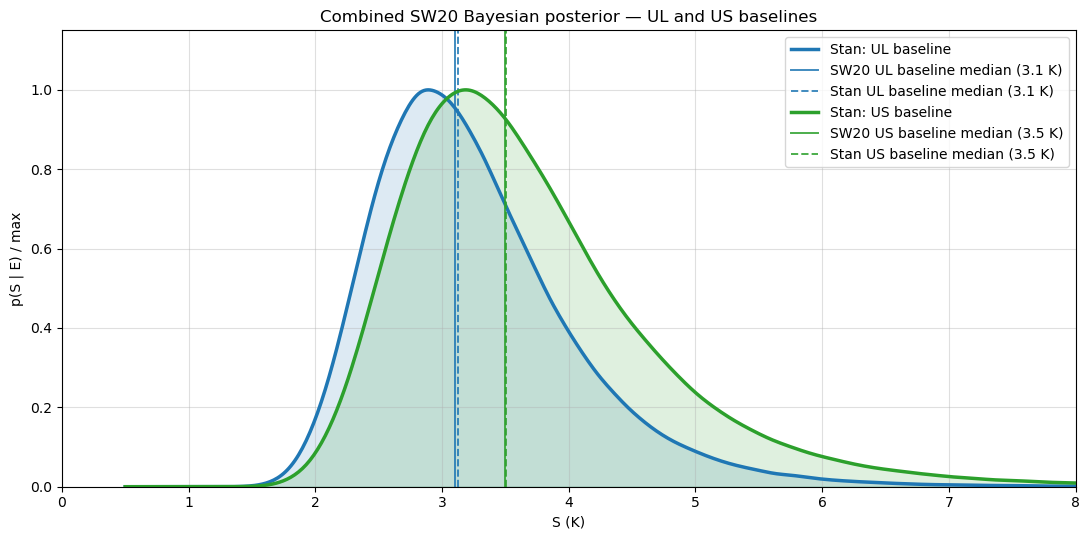

In [15]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(sw20_S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (sw20_S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid); pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)
    
    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlabel('S (K)'); ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()

# coop version

### Revised historical structure only

In [11]:
# WRite the data to json
# we'll write to versions, one with uniform lambda flag, one with uniform S flag/ 
cmdstanpy.write_stan_json('/tmp/baseline_UL.json', coop_data_UL)
cmdstanpy.write_stan_json('/tmp/baseline_US.json', coop_data_US)

common = dict(inits=init, chains=N_CHAINS,
              iter_warmup=N_WARMUP, iter_sampling=N_SAMPLES,
              adapt_delta=0.95, show_progress=False)

coop_fit_UL = coop_model.sample(data='/tmp/baseline_UL.json', **common)
coop_fit_US = coop_model.sample(data='/tmp/baseline_US.json', **common)

coop_S_UL = coop_fit_UL.draws_xr(vars=['S']).S.values.ravel()
coop_S_US = coop_fit_US.draws_xr(vars=['S']).S.values.ravel()

13:53:13 - cmdstanpy - INFO - CmdStan start processing
13:53:13 - cmdstanpy - INFO - Chain [1] start processing
13:53:13 - cmdstanpy - INFO - Chain [2] start processing
13:53:13 - cmdstanpy - INFO - Chain [3] start processing
13:53:13 - cmdstanpy - INFO - Chain [4] start processing
13:53:31 - cmdstanpy - INFO - Chain [3] done processing
13:53:32 - cmdstanpy - INFO - Chain [1] done processing
13:53:32 - cmdstanpy - INFO - Chain [2] done processing
13:53:35 - cmdstanpy - INFO - Chain [4] done processing
13:53:35 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'Cooper_SW20.stan', line 195, column 4 to column 45)
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'Cooper_SW20.stan', line 195, column 4 to column 45)
Consider re-running with show_console=True if the above output is unclear!
13:53:47 - cmdstanpy - INFO - CmdStan start processing
13:53:47 - cmdstanpy - INFO - Chain [1] sta

In [16]:
line('UL baseline', coop_S_UL, coop_fit_UL, SHERWOOD_UL)
line('US baseline', coop_S_US, coop_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.36 +/- 0.86
  divergences   : 0

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.27 2.61  3.21 4.07  4.95   3.36

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.84 +/- 1.16
  divergences   : 0

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.47 2.87  3.62 4.74  5.96   3.84



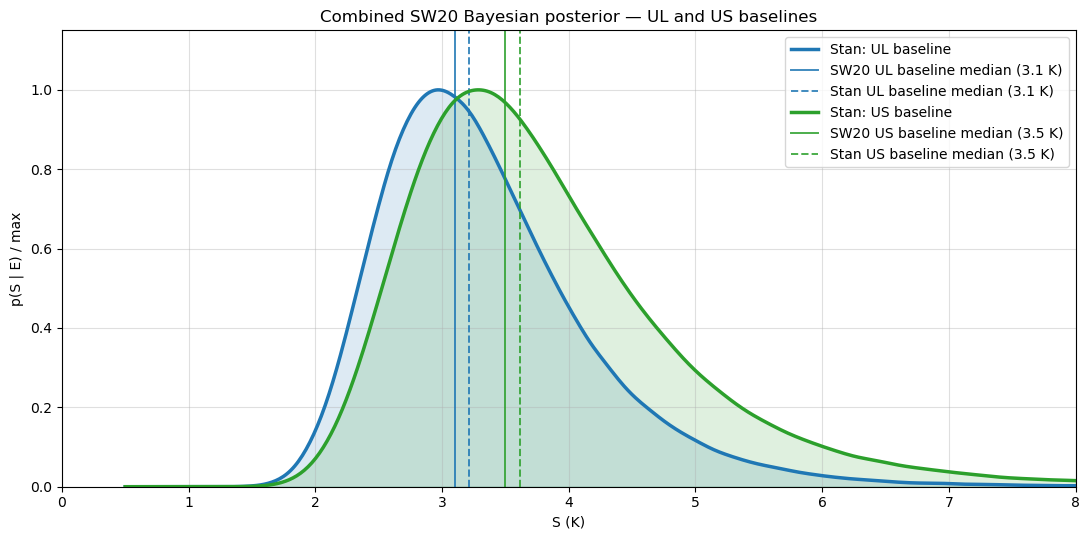

In [17]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(coop_S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (coop_S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid); pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)
    
    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlabel('S (K)'); ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()

### Revised code and inputs

In [24]:
# WRite the data to json
# we'll write to versions, one with uniform lambda flag, one with uniform S flag/ 
cmdstanpy.write_stan_json('/tmp/baseline_UL.json', coopREV_data_UL)
cmdstanpy.write_stan_json('/tmp/baseline_US.json', coopREV_data_US)

common = dict(inits=initREV, chains=N_CHAINS,
              iter_warmup=N_WARMUP, iter_sampling=N_SAMPLES,
              adapt_delta=0.95, show_progress=False)

coopREV_fit_UL = coopREV_model.sample(data='/tmp/baseline_UL.json', **common)
coopREV_fit_US = coopREV_model.sample(data='/tmp/baseline_US.json', **common)

coopREV_S_UL = coopREV_fit_UL.draws_xr(vars=['S']).S.values.ravel()
coopREV_S_US = coopREV_fit_US.draws_xr(vars=['S']).S.values.ravel()

14:33:03 - cmdstanpy - INFO - CmdStan start processing
14:33:03 - cmdstanpy - INFO - Chain [1] start processing
14:33:03 - cmdstanpy - INFO - Chain [2] start processing
14:33:03 - cmdstanpy - INFO - Chain [3] start processing
14:33:03 - cmdstanpy - INFO - Chain [4] start processing
14:33:38 - cmdstanpy - INFO - Chain [2] done processing
14:33:41 - cmdstanpy - INFO - Chain [1] done processing
14:33:43 - cmdstanpy - INFO - Chain [4] done processing
14:33:45 - cmdstanpy - INFO - Chain [3] done processing
14:33:57 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 6 divergent transitions (0.0%)
	Chain 2 had 15 divergent transitions (0.0%)
	Chain 3 had 4 divergent transitions (0.0%)
	Chain 4 had 3 divergent transitions (0.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.
14:33:57 - cmdstanpy - INFO - CmdStan start processing
14:33:57 - cmdstanpy - INFO - Chain [1] start processing
14:33:57 - cmdstanpy - INFO - Chain [2] start p

In [19]:
## after process change
line('UL baseline', coopREV_S_UL, coopREV_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_S_US, coopREV_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.28 +/- 0.94
  divergences   : 68

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.17 2.50  3.09 3.98  4.97   3.28

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.93 +/- 1.59
  divergences   : 110

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.38 2.78  3.56 4.87  6.61   3.93



In [24]:
## after process change, but lower corr
line('UL baseline', coopREV_S_UL, coopREV_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_S_US, coopREV_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.25 +/- 0.90
  divergences   : 246

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.17 2.49  3.07 3.94  4.88   3.25

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.84 +/- 1.45
  divergences   : 442

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.37 2.75  3.51 4.75  6.32   3.84



In [18]:
## before process change
line('UL baseline', coopREV_S_UL, coopREV_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_S_US, coopREV_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.00 +/- 0.76
  divergences   : 124

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.06 2.35  2.87 3.61  4.39   3.00

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.44 +/- 1.14
  divergences   : 124

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.22 2.56  3.20 4.20  5.38   3.44



In [25]:
## reduce inflation of paleo pattern effect
line('UL baseline', coopREV_S_UL, coopREV_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_S_US, coopREV_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.10 +/- 0.74
  divergences   : 28

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.15 2.44  2.97 3.71  4.46   3.10

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.48 +/- 1.00
  divergences   : 108

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.31 2.66  3.29 4.23  5.25   3.48



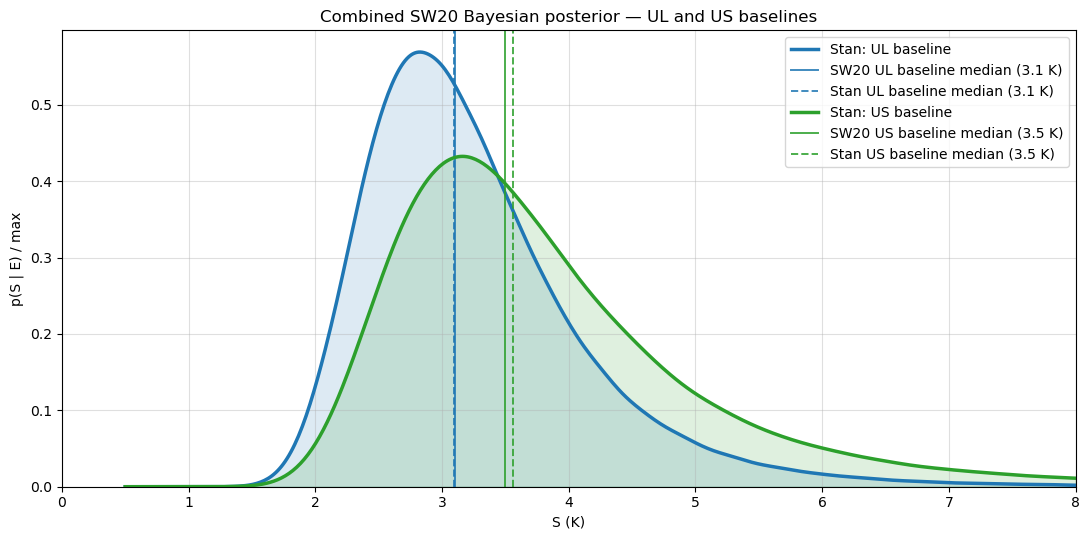

In [20]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(coopREV_S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (coopREV_S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid)#; pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)
    
    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

# ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlim(0, 8); ax.set_ylim(0,)
ax.set_xlabel('S (K)'); ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()

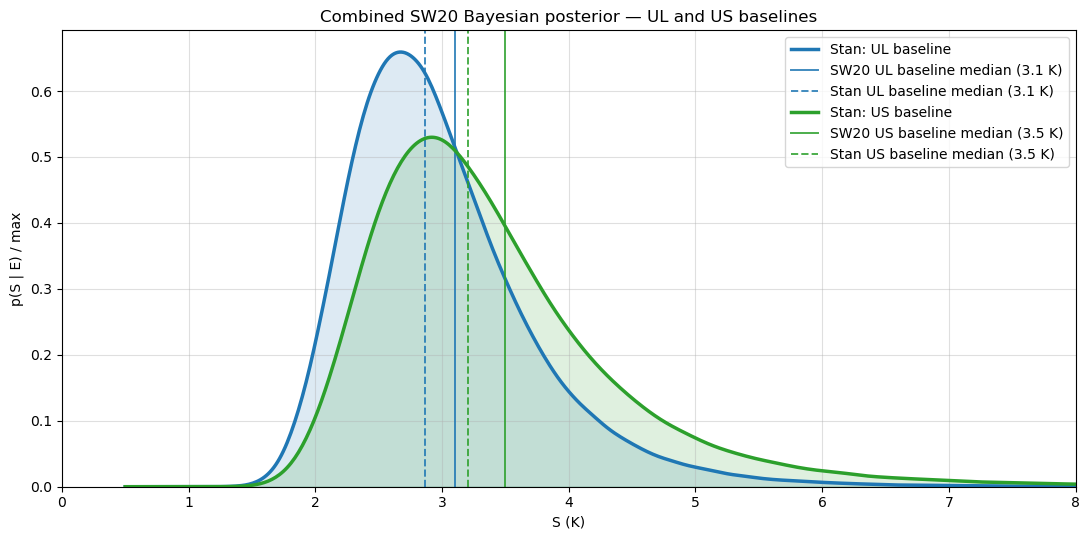

In [20]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(coopREV_S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (coopREV_S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid)#; pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)
    
    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

# ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlim(0, 8); ax.set_ylim(0,)
ax.set_xlabel('S (K)'); ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()

## Score N residual version

In [12]:
# WRite the data to json
# we'll write to versions, one with uniform lambda flag, one with uniform S flag/ 
cmdstanpy.write_stan_json('/tmp/baseline_UL.json', coopREV_data_UL)
cmdstanpy.write_stan_json('/tmp/baseline_US.json', coopREV_data_US)

common = dict(inits=initREV, chains=N_CHAINS,
              iter_warmup=N_WARMUP, iter_sampling=N_SAMPLES,
              adapt_delta=0.95, show_progress=False)

coopREV_Nresid_fit_UL = coopREV_model.sample(data='/tmp/baseline_UL.json', **common)
coopREV_Nresid_fit_US = coopREV_model.sample(data='/tmp/baseline_US.json', **common)

coopREV_Nresid_S_UL = coopREV_Nresid_fit_UL.draws_xr(vars=['S']).S.values.ravel()
coopREV_Nresid_S_US = coopREV_Nresid_fit_US.draws_xr(vars=['S']).S.values.ravel()

In [15]:
## before process change
line('UL baseline', coopREV_Nresid_S_UL, coopREV_Nresid_fit_US, SHERWOOD_UL)
line('US baseline', coopREV_Nresid_S_US, coopREV_Nresid_fit_UL, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.25 +/- 0.90
  divergences   : 392

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.17 2.49  3.08 3.94  4.87   3.25

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.84 +/- 1.48
  divergences   : 219

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.36 2.75  3.51 4.75  6.33   3.84



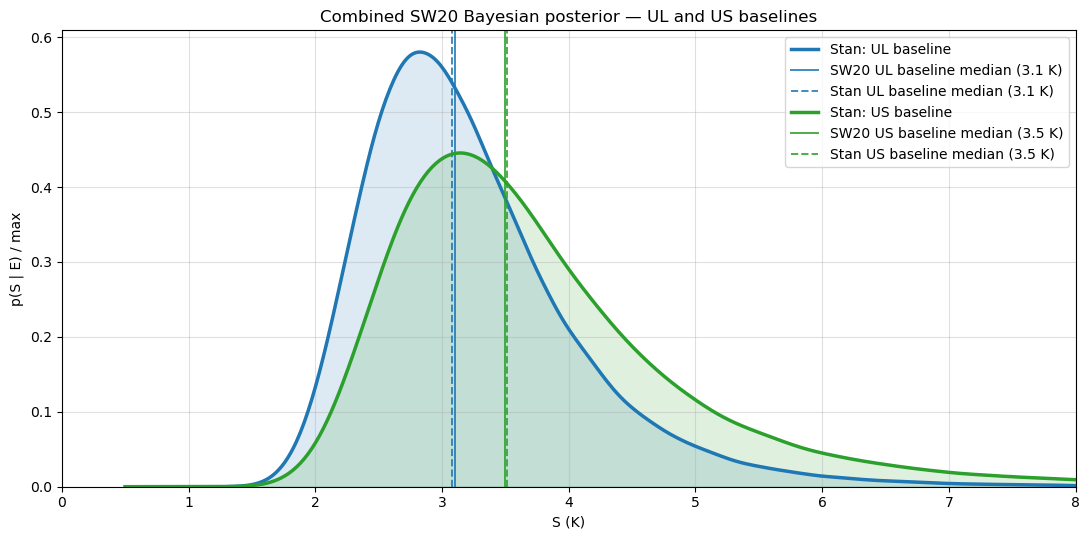

In [17]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(coopREV_Nresid_S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (coopREV_Nresid_S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid)#; pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)
    
    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

# ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlim(0, 8); ax.set_ylim(0,)
ax.set_xlabel('S (K)'); ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()

# Likelihoods

In [ ]:
f_other_lgm_rev.mean()

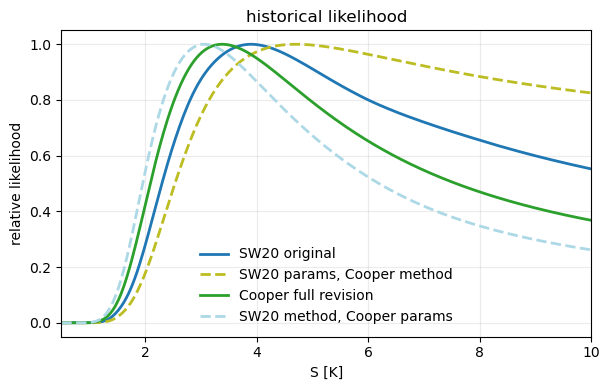

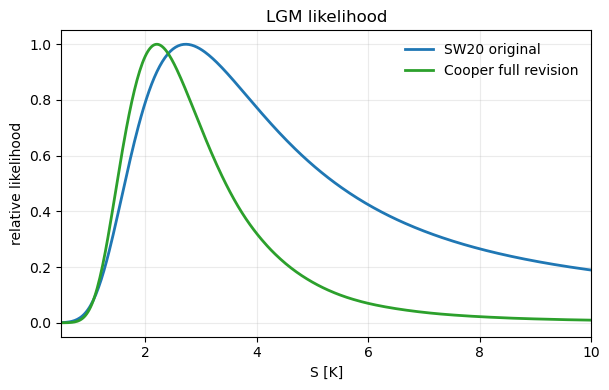

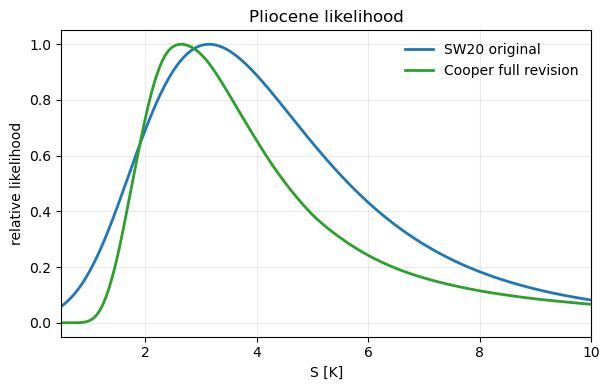

In [23]:
## line-of-evidence likelihood curves for S
from scipy.stats import norm

S_like_grid = np.linspace(0.5, 10.0, 400)
like_mc_n = 50000
like_rng = np.random.default_rng(123)


def _split_normal(mu, sig_low, sig_high, n):
    z = like_rng.normal(size=n)
    return np.where(z < 0, mu + z * sig_low, mu + z * sig_high)


def _draw(d, mu, sig):
    return like_rng.normal(d[mu], d[sig], like_mc_n)


def _rel(y):
    y = np.asarray(y, dtype=float)
    return y / np.nanmax(y)


## sw20 nuisance draws, reused for sw20 original and cooper-sw20 comparisons
f2x_sw = _draw(SW20_BASE, "mu_F2xCO2", "sig_F2xCO2")
zeta_sw = _draw(SW20_BASE, "mu_zeta", "sig_zeta")
f_hist_sw = _split_normal(
    SW20_BASE["mu_F_hist"],
    SW20_BASE["sig_F_hist_low"],
    SW20_BASE["sig_F_hist_high"],
    like_mc_n,
)
n_hist_sw = _draw(SW20_BASE, "mu_N_hist", "sig_N_hist")
t_hist_sw = _draw(SW20_BASE, "mu_T_hist", "sig_T_hist")
dl_hist_sw = _draw(SW20_BASE, "mu_dlambda", "sig_dlambda")
t_lgm_sw = _draw(SW20_BASE, "mu_T_LGM", "sig_T_LGM")
alpha_sw = _draw(SW20_BASE, "mu_alpha", "sig_alpha")
co2_plio_sw = _draw(SW20_BASE, "mu_CO2_plio", "sig_CO2_plio")
fch4_sw = _draw(SW20_BASE, "mu_fCH4", "sig_fCH4")
fess_sw = _draw(SW20_BASE, "mu_fESS", "sig_fESS")

## cooper revised nuisance draws
f2x_rev = _draw(coop_REVISED, "mu_F2xCO2", "sig_F2xCO2")
zeta_rev = _draw(coop_REVISED, "mu_zeta", "sig_zeta")
f_hist_rev = _draw(coop_REVISED, "mu_F_hist", "sig_F_hist")
t_hist_rev = _draw(coop_REVISED, "mu_T_hist", "sig_T_hist")
n_hist_rev = _draw(coop_REVISED, "mu_N_hist", "sig_N_hist")
dl_hist_rev = _draw(coop_REVISED, "mu_dlambda", "sig_dlambda")
f_other_lgm_rev = _draw(coop_REVISED, "mu_F_other_LGM", "sig_F_other_LGM")
co2_plio_rev = _draw(coop_REVISED, "mu_CO2_plio", "sig_CO2_plio")
fch4_rev = _draw(coop_REVISED, "mu_fCH4", "sig_fCH4")
f_plio_nonghg_rev = _draw(coop_REVISED, "mu_F_plio_nonGHG", "sig_F_plio_nonGHG")

dl_cov_rev = np.array(
    [
        [coop_REVISED["sig_dlambda_LGM"] ** 2,
         coop_REVISED["rho_dlambda_LGM_plio"] * coop_REVISED["sig_dlambda_LGM"] * coop_REVISED["sig_dlambda_plio"]],
        [coop_REVISED["rho_dlambda_LGM_plio"] * coop_REVISED["sig_dlambda_LGM"] * coop_REVISED["sig_dlambda_plio"],
         coop_REVISED["sig_dlambda_plio"] ** 2],
    ]
)
dl_paleo_rev = like_rng.multivariate_normal(
    [coop_REVISED["mu_dlambda_LGM"], coop_REVISED["mu_dlambda_plio"]],
    dl_cov_rev,
    size=like_mc_n,
)
dl_lgm_rev = dl_paleo_rev[:, 0]
dl_plio_rev = dl_paleo_rev[:, 1]

curves = {"historical": {}, "LGM": {}, "Pliocene": {}}

for S in S_like_grid:
    l_sw = -f2x_sw / S
    l_rev = -f2x_rev / S

    ## historical: sw20 original predicts T; cooper versions predict N
    t_hist_sw_pred = -(f_hist_sw - n_hist_sw) / (l_sw - dl_hist_sw)
    n_hist_sw_pred = f_hist_sw + t_hist_sw * (l_sw - dl_hist_sw)
    t_hist_rev_pred = -(f_hist_rev - n_hist_rev) / (l_rev - dl_hist_rev)
    n_hist_rev_pred = f_hist_rev + t_hist_rev * (l_rev - dl_hist_rev)

    curves["historical"].setdefault("SW20 original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_hist"], loc=t_hist_sw_pred, scale=SW20_BASE["sig_T_hist"]))
    )
    curves["historical"].setdefault("SW20 params, Cooper method", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_N_hist"], loc=n_hist_sw_pred, scale=SW20_BASE["sig_N_hist"]))
    )
    curves["historical"].setdefault("Cooper full revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_N_hist"], loc=n_hist_rev_pred, scale=coop_REVISED["sig_N_hist"]))
    )
    curves["historical"].setdefault("SW20 method, Cooper params", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_T_hist"], loc=t_hist_rev_pred, scale=coop_REVISED["sig_T_hist"]))
    )

    ## LGM: sw20/cooper-sw20 predict F; cooper revised predicts T
    f_lgm_sw_pred = 0.57 * f2x_sw - t_lgm_sw * (l_sw / (1 + zeta_sw) + alpha_sw / 2 * t_lgm_sw)
    t_lgm_rev_pred = (f_other_lgm_rev - 0.57 * f2x_rev) / (dl_lgm_rev - l_rev / (1 + zeta_rev))

    curves["LGM"].setdefault("SW20 original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_F_LGM"], loc=f_lgm_sw_pred, scale=SW20_BASE["sig_F_LGM"]))
    )
    # curves["LGM"].setdefault("Cooper, SW20 params", []).append(
    #     np.nanmean(norm.pdf(SW20_BASE["mu_F_LGM"], loc=f_lgm_sw_pred, scale=SW20_BASE["sig_F_LGM"]))
    # )
    curves["LGM"].setdefault("Cooper full revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_T_LGM"], loc=t_lgm_rev_pred, scale=coop_REVISED["sig_T_LGM"]))
    )

    ## Pliocene: sw20/cooper-sw20 original equation; cooper revised equation
    f_plio_co2_sw = np.log(co2_plio_sw / 284) / np.log(2) * f2x_sw
    t_plio_sw_pred = (-f_plio_co2_sw * (1 + fch4_sw) * (1 + fess_sw)) / (l_sw / (1 + zeta_sw))

    f_plio_co2_rev = np.log(co2_plio_rev / 284) / np.log(2) * f2x_rev
    t_plio_rev_pred = (-f_plio_co2_rev * (1 + fch4_rev) - f_plio_nonghg_rev) / (
        l_rev / (1 + zeta_rev) - dl_plio_rev
    )

    curves["Pliocene"].setdefault("SW20 original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_plio"], loc=t_plio_sw_pred, scale=SW20_BASE["sig_T_plio"]))
    )
    # curves["Pliocene"].setdefault("Cooper, SW20 params", []).append(
    #     np.nanmean(norm.pdf(SW20_BASE["mu_T_plio"], loc=t_plio_sw_pred, scale=SW20_BASE["sig_T_plio"]))
    # )
    curves["Pliocene"].setdefault("Cooper full revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_T_plio"], loc=t_plio_rev_pred, scale=coop_REVISED["sig_T_plio"]))
    )

styles = {
    "SW20 original": dict(color="tab:blue", ls="-"),
    "SW20 params, Cooper method": dict(color="tab:olive", ls="--"),
    "Cooper full revision": dict(color="tab:green", ls="-"),
    "SW20 method, Cooper params": dict(color="lightblue", ls="--"),
}

for evidence, evidence_curves in curves.items():
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for label, y in evidence_curves.items():
        ax.plot(S_like_grid, _rel(y), lw=2, label=label, **styles[label])
    ax.set(xlabel="S [K]", ylabel="relative likelihood", title=f"{evidence} likelihood")
    ax.set_xlim(S_like_grid.min(), S_like_grid.max())
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()



<!-- ENERGY_BUDGET_EQUATIONS_SINGLE_CELL -->

## Energy-Budget Likelihood Equations

Using the signed feedback convention in the Stan code:

$$
\lambda \equiv -\frac{F_{2\times\mathrm{CO}_2}}{S}
$$

<!-- HISTORICAL_PARAMETER_TABLE -->

### Historical Parameter Values

<table>
  <thead>
    <tr>
      <th rowspan="2">Parameter</th>
      <th colspan="3">SW20 ($\overline{2006\text{–}2018}$ vs. $\overline{1861\text{–}1880}$)</th>
      <th colspan="3">Revision ($\overline{2006\text{–}2024}$ vs. $\overline{1850\text{–}1900}$)</th>
    </tr>
    <tr>
      <th>Median</th>
      <th>$1\sigma$</th>
      <th>5-95%</th>
      <th>Median</th>
      <th>$1\sigma$</th>
      <th>5-95%</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>T</td>
      <td>1.03</td>
      <td>0.09</td>
      <td>0.89 to 1.17</td>
      <td>1.08</td>
      <td>0.11</td>
      <td>0.90 to 1.26</td>
    </tr>
    <tr>
      <td>N</td>
      <td>0.60</td>
      <td>0.18</td>
      <td>0.30 to 0.90</td>
      <td>0.71</td>
      <td>0.20</td>
      <td>0.38 to 1.04</td>
    </tr>
    <tr>
      <td>F</td>
      <td>1.83</td>
      <td>skewed</td> <!-- !-1.13 / +0.53 -->
      <td>-0.03 to 2.71</td>
      <td>2.65</td>
      <td>0.41</td>
      <td>1.98 to 3.32</td>
    </tr>
    <tr>
      <td>$\Delta \lambda$</td>
      <td>0.50</td>
      <td>0.30</td>
      <td>0.00 to 1.00</td>
      <td>0.62</td>
      <td>0.33</td>
      <td>0.08 to 1.16</td>
    </tr>
  </tbody>
</table>

For symmetric parameters, the 5-95% range is median +/- 1.645 sigma. SW20 historical F uses the asymmetric split-normal uncertainty implemented in the likelihood code.

### Process

**SW20**

$$
\lambda \sim \mathcal{N}\left(\mu_{\lambda,\mathrm{SW20}},\sigma_{\lambda,\mathrm{SW20}}\right)
$$

**Cooper full revision**

$$
\lambda \sim \mathcal{N}\left(\mu_{\lambda,\mathrm{Cooper}},\sigma_{\lambda,\mathrm{Cooper}}\right)
$$

### Historical

**SW20**

$$
\Delta T_{\mathrm{hist}}
= -\frac{\Delta F_{\mathrm{hist}} - \Delta N_{\mathrm{hist}}}
{\lambda - \Delta\lambda_{\mathrm{hist}}}
$$

**Cooper full revision**

$$
\Delta N_{\mathrm{hist}}
= \Delta F_{\mathrm{hist}}
+ \Delta T_{\mathrm{hist}}\left(\lambda - \Delta\lambda_{\mathrm{hist}}\right)
$$

### Last Glacial Maximum

**SW20**

$$
\Delta F_{\mathrm{LGM}}
= 0.57\,F_{2\times\mathrm{CO}_2}
- \Delta T_{\mathrm{LGM}}
\left(
\frac{\lambda}{1+\zeta}
+ \frac{\alpha}{2}\Delta T_{\mathrm{LGM}}
\right)
$$

**Cooper full revision**

$$
\Delta T_{\mathrm{LGM}}
= \frac{-\Delta F_{\mathrm{CO}_2,\mathrm{LGM}} - \Delta F_{\mathrm{NonCO}_2,\mathrm{LGM}}}
{\lambda/(1+\zeta) - \Delta\lambda_{\mathrm{LGM}}}
$$

where

$$
\Delta F_{\mathrm{CO}_2,\mathrm{LGM}} \equiv -0.57\,F_{2\times\mathrm{CO}_2}.
$$

### Pliocene

with

$$
\Delta F_{\mathrm{CO}_2,\mathrm{Plio}}
= \frac{\log\left(C_{\mathrm{Plio}}/284\right)}{\log 2}\,F_{2\times\mathrm{CO}_2}
$$

**SW20**

$$
\Delta T_{\mathrm{Plio}}
= \frac{-\Delta F_{\mathrm{CO}_2,\mathrm{Plio}}
\left(1 + f_{\mathrm{CH}_4}\right)
\left(1 + f_{\mathrm{ESS}}\right)}
{\lambda/(1+\zeta)}
$$

**Cooper full revision**

$$
\Delta T_{\mathrm{Plio}}
= \frac{-\Delta F_{\mathrm{CO}_2,\mathrm{Plio}}\left(1 + f_{\mathrm{CH}_4}\right)
- \Delta F_{\mathrm{NonGHG},\mathrm{Plio}}}
{\lambda/(1+\zeta) - \Delta\lambda_{\mathrm{Plio}}}
$$
